<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/artist_trapeze_velocity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trapeze Artist Forward Velocity vs Bar Final Swing Direction

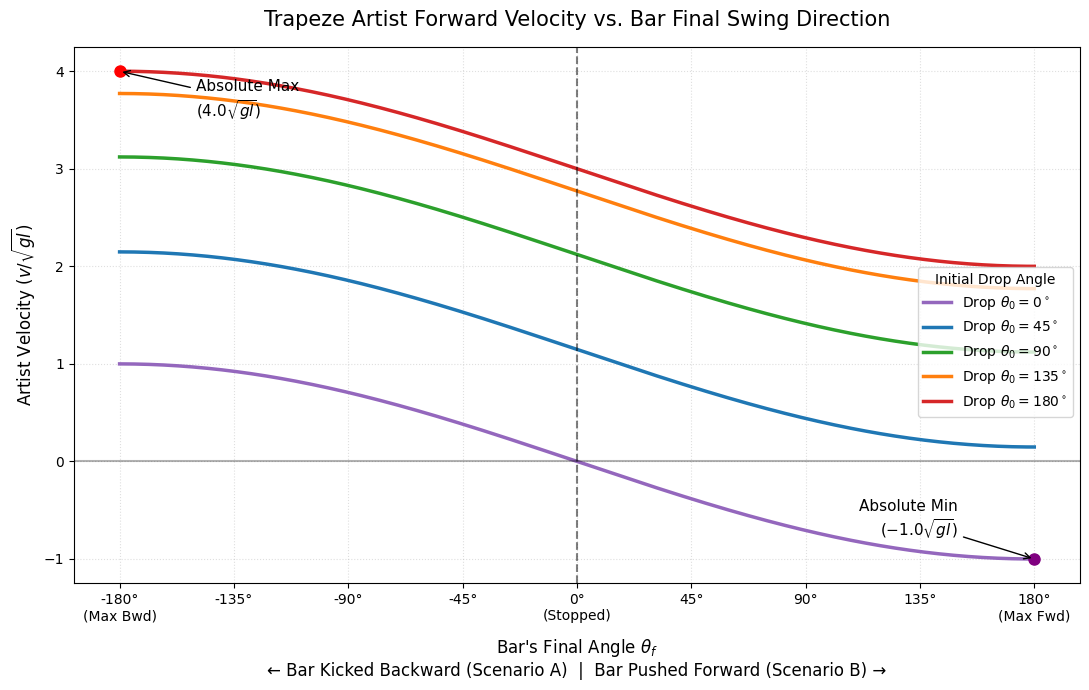

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of directed final angles (from -180 to +180)
# Negative values represent Scenario A (Bar swings backward)
# Positive values represent Scenario B (Bar swings forward)
theta_f_deg = np.linspace(-180, 180, 500)
theta_f_rad = np.radians(theta_f_deg)

# Function to calculate normalized artist velocity (v / sqrt(gl))
def calc_velocity(theta_0_deg, theta_f_rad_directed):
    # Convert start angle to radians
    theta_0_rad = np.radians(theta_0_deg)

    # Calculate the base momentum from the initial drop
    base_term = 3 * np.sqrt(1 - np.cos(theta_0_rad))

    # Calculate the magnitude of the momentum component from the final bar swing
    term_f = np.sqrt(1 - np.cos(theta_f_rad_directed))

    # Determine the sign based on the scenario:
    # If theta_f is negative (backward), we ADD the momentum term (Scenario A)
    # If theta_f is positive (forward), we SUBTRACT the momentum term (Scenario B)
    # np.sign() gives -1 for negative inputs, so multiplying by -1 yields the correct addition/subtraction.
    sign_multiplier = -np.sign(theta_f_rad_directed)

    # Calculate final normalized velocity
    v_normalized = (np.sqrt(2) / 2) * (base_term + sign_multiplier * term_f)
    return v_normalized

# Create the plot
plt.figure(figsize=(11, 7))

# Plot the curves for various starting drop angles
theta_0_list = [0, 45, 90, 135, 180]
colors = ['#9467bd', '#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

for th_0, color in zip(theta_0_list, colors):
    v = calc_velocity(th_0, theta_f_rad)
    plt.plot(theta_f_deg, v, label=f'Drop $\\theta_0 = {th_0}^\\circ$', color=color, linewidth=2.5)

# Formatting the plot axes and grid
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)

plt.title("Trapeze Artist Forward Velocity vs. Bar Final Swing Direction", fontsize=15, pad=15)
plt.xlabel("Bar's Final Angle $\\theta_f$\n← Bar Kicked Backward (Scenario A)  |  Bar Pushed Forward (Scenario B) →", fontsize=12, labelpad=10)
plt.ylabel("Artist Velocity ($v / \\sqrt{gl}$)", fontsize=12)

# Custom x-ticks to clarify the scenarios
plt.xticks([-180, -135, -90, -45, 0, 45, 90, 135, 180],
           ['-180°\n(Max Bwd)', '-135°', '-90°', '-45°', '0°\n(Stopped)', '45°', '90°', '135°', '180°\n(Max Fwd)'])

# --- Annotate the Absolute Mathematical Bounds ---
# 1. Absolute Max: 180 deg start + 180 deg backward swing yields max velocity of 4.0
plt.plot(-180, 4.0, marker='o', markersize=8, color='red')
plt.annotate('Absolute Max\n($4.0\\sqrt{gl}$)', xy=(-180, 4.0), xytext=(-150, 3.7),
             arrowprops=dict(facecolor='black', arrowstyle='->'), verticalalignment='center', fontsize=11)

# 2. Absolute Min: 0 deg start + 180 deg forward swing yields min velocity of -1.0
plt.plot(180, -1.0, marker='o', markersize=8, color='purple')
plt.annotate('Absolute Min\n($-1.0\\sqrt{gl}$)', xy=(180, -1.0), xytext=(150, -0.6),
             arrowprops=dict(facecolor='black', arrowstyle='->'), horizontalalignment='right', verticalalignment='center', fontsize=11)

# Finalize layout and show
plt.legend(title="Initial Drop Angle", loc='center right', bbox_to_anchor=(1.0, 0.45), fontsize=10)
plt.grid(True, alpha=0.4, linestyle=':')
plt.tight_layout()

# Display the plot
plt.show()